# KH6006 – Coursework 1 – Part 3
## K-Means Clustering using CUDA
**Youssef Mohamed Hanafy | ID: 202000009**


**K = 8 clusters | 100 iterations**



## Step 1 – Check the GPU

In [1]:
!nvidia-smi

Tue Apr 14 07:18:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 – Download and prepare the dataset

In [2]:
import pandas as pd
import numpy as np

print('Downloading NYC Yellow Taxi Trip Data (Jan 2023)...')
url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet'
df = pd.read_parquet(url)
print(f'Loaded: {len(df):,} rows x {len(df.columns)} columns')

# Use trip_distance and fare_amount — both numeric and meaningful
features = df[['trip_distance', 'fare_amount']].astype(float)

# Drop invalid rows (negative fares or distances)
features = features[(features['trip_distance'] > 0) & (features['fare_amount'] > 0)]

# Normalize to 0-100
features = (features - features.min()) / (features.max() - features.min() + 1e-9) * 100.0
features = features.values.astype(np.float32)

print(f'Points ready: {len(features):,}')

# Save to binary file for the CUDA program
features.tofile('points.bin')
print('Saved points.bin — ready for CUDA')

Loaded: 3,066,766 rows x 19 columns
Points ready: 2,998,382
Saved points.bin — ready for CUDA


In [3]:
# print the dataset
print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2023-01-01 00:32:10   2023-01-01 00:40:36              1.0   
1         2  2023-01-01 00:55:08   2023-01-01 01:01:27              1.0   
2         2  2023-01-01 00:25:04   2023-01-01 00:37:49              1.0   
3         1  2023-01-01 00:03:48   2023-01-01 00:13:25              0.0   
4         2  2023-01-01 00:10:29   2023-01-01 00:21:19              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           0.97         1.0                  N           161           141   
1           1.10         1.0                  N            43           237   
2           2.51         1.0                  N            48           238   
3           1.90         1.0                  N           138             7   
4           1.43         1.0                  N           107            79   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \


## Step 3 – Write the CUDA code


In [4]:
%%writefile kmeans.cu
#include <stdio.h>
#include <stdlib.h>
#include <float.h>
#include <time.h>
#include <cuda_runtime.h>

#define K      8     
#define ITER   100   
#define BLOCK  256   // threads per block

// ─────────────────────────────────────────────────────────────────────
// GPU KERNEL: Assignment Step
// One thread per data point. Each thread finds its nearest centroid.
// ─────────────────────────────────────────────────────────────────────
__global__ void assign_kernel(
    float* points,    // [N x 2] all data points
    float* centroids, // [K x 2] current centroids
    int*   labels,    // [N]     output: cluster label per point
    int n, int k)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    float best_dist = FLT_MAX;
    int   best_k    = 0;
    float px = points[i * 2];
    float py = points[i * 2 + 1];

    for (int c = 0; c < k; c++) {
        float dx   = px - centroids[c * 2];
        float dy   = py - centroids[c * 2 + 1];
        float dist = dx*dx + dy*dy;
        if (dist < best_dist) {
            best_dist = dist;
            best_k    = c;
        }
    }
    labels[i] = best_k;
}

// ─────────────────────────────────────────────────────────────────────
// CPU: Update Step — recompute centroids from assigned points
// ─────────────────────────────────────────────────────────────────────
void update_centroids_cpu(float* points, int* labels,
                          float* centroids, int n, int k)
{
    float sum_x[K] = {0}, sum_y[K] = {0};
    int   count[K] = {0};
    for (int i = 0; i < n; i++) {
        int c = labels[i];
        sum_x[c] += points[i * 2];
        sum_y[c] += points[i * 2 + 1];
        count[c]++;
    }
    for (int c = 0; c < k; c++)
        if (count[c] > 0) {
            centroids[c * 2]     = sum_x[c] / count[c];
            centroids[c * 2 + 1] = sum_y[c] / count[c];
        }
}

// ─────────────────────────────────────────────────────────────────────
// CPU-only sequential K-Means (baseline for comparison)
// ─────────────────────────────────────────────────────────────────────
void cpu_kmeans(float* points, float* centroids, int* labels, int n, int k)
{
    for (int iter = 0; iter < ITER; iter++) {
        for (int i = 0; i < n; i++) {
            float best = FLT_MAX; int best_k = 0;
            float px = points[i*2], py = points[i*2+1];
            for (int c = 0; c < k; c++) {
                float dx = px - centroids[c*2];
                float dy = py - centroids[c*2+1];
                float d  = dx*dx + dy*dy;
                if (d < best) { best = d; best_k = c; }
            }
            labels[i] = best_k;
        }
        update_centroids_cpu(points, labels, centroids, n, k);
    }
}

// ─────────────────────────────────────────────────────────────────────
// MAIN
// ─────────────────────────────────────────────────────────────────────
int main()
{
    // ── Load NYC Yellow Taxi Trip Data from binary file ───────────────────
    FILE* f = fopen("points.bin", "rb");
    if (!f) { fprintf(stderr, "Cannot open points.bin\n"); return 1; }
    fseek(f, 0, SEEK_END);
    long fsize = ftell(f);
    rewind(f);
    int n = (int)(fsize / (2 * sizeof(float)));
    float* h_points = (float*)malloc(fsize);
    fread(h_points, sizeof(float), n * 2, f);
    fclose(f);

    int k = K;
    printf("Dataset : NYC Yellow Taxi Trip Data (Jan 2023)\n");
    printf("Points  : %d\n", n);
    printf("Clusters: %d\n", k);
    printf("Iters   : %d\n", ITER);
    printf("Memory  : %.1f MB\n", fsize / 1e6);
    printf("-------------------------------------------\n");

    float* h_centroids = (float*)malloc(k * 2 * sizeof(float));
    float* h_cent_cpu  = (float*)malloc(k * 2 * sizeof(float));
    int*   h_labels    = (int*)  malloc(n     * sizeof(int));

    // use first K points as starting centroids
    for (int i = 0; i < k * 2; i++) {
        h_centroids[i] = h_points[i];
        h_cent_cpu[i]  = h_points[i];
    }

    // ════════════════════════════════════════════════════════
    // CPU TIMING
    // ════════════════════════════════════════════════════════
    struct timespec t0, t1;
    clock_gettime(CLOCK_MONOTONIC, &t0);
    cpu_kmeans(h_points, h_cent_cpu, h_labels, n, k);
    clock_gettime(CLOCK_MONOTONIC, &t1);
    double cpu_sec = (t1.tv_sec - t0.tv_sec)
                   + (t1.tv_nsec - t0.tv_nsec) / 1e9;
    printf("CPU time : %.4f s\n", cpu_sec);

    // ════════════════════════════════════════════════════════
    // GPU SETUP
    // ════════════════════════════════════════════════════════
    float *d_points, *d_centroids;
    int   *d_labels;
    cudaMalloc(&d_points,    n * 2 * sizeof(float));
    cudaMalloc(&d_centroids, k * 2 * sizeof(float));
    cudaMalloc(&d_labels,    n     * sizeof(int));
    cudaMemcpy(d_points, h_points, n * 2 * sizeof(float),
               cudaMemcpyHostToDevice);

    int blocks = (n + BLOCK - 1) / BLOCK;

    // ════════════════════════════════════════════════════════
    // GPU TIMING
    // ════════════════════════════════════════════════════════
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventRecord(start);

    for (int iter = 0; iter < ITER; iter++) {
        cudaMemcpy(d_centroids, h_centroids,
                   k * 2 * sizeof(float), cudaMemcpyHostToDevice);
        assign_kernel<<<blocks, BLOCK>>>(
            d_points, d_centroids, d_labels, n, k);
        cudaMemcpy(h_labels, d_labels,
                   n * sizeof(int), cudaMemcpyDeviceToHost);
        update_centroids_cpu(h_points, h_labels, h_centroids, n, k);
    }

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    double gpu_sec = ms / 1000.0;

    printf("GPU time : %.4f s\n", gpu_sec);
    printf("Speedup  : %.2fx\n",  cpu_sec / gpu_sec);
    printf("-------------------------------------------\n");
    printf("GPU blocks per iter : %d\n", blocks);
    printf("GPU threads per iter: %d\n", blocks * BLOCK);

    free(h_points); free(h_centroids); free(h_cent_cpu); free(h_labels);
    cudaFree(d_points); cudaFree(d_centroids); cudaFree(d_labels);
    return 0;
}

Writing kmeans.cu


## Step 4 – Compile and Run
The CPU part will take ~1–3 minutes. That is expected — 494,000 points × 8 centroids × 100 iterations sequentially is very slow, which is exactly why we use the GPU.

In [5]:
%%bash
nvcc -O2 -o kmeans kmeans.cu -lm
echo "Compiled OK. Running now..."
./kmeans

Compiled OK. Running now...
Dataset : NYC Yellow Taxi Trip Data (Jan 2023)
Points  : 2998382
Clusters: 8
Iters   : 100
Memory  : 24.0 MB
-------------------------------------------
CPU time : 4.1552 s
GPU time : 0.8078 s
Speedup  : 5.14x
-------------------------------------------
GPU blocks per iter : 11713
GPU threads per iter: 2998528


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
kmeans.cu(96): warning #1650-D: result of call is not used
      fread(h_points, sizeof(float), n * 2, f);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

kmeans.cu(96): warning #1650-D: result of call is not used
      fread(h_points, sizeof(float), n * 2, f);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

kmeans.cu: In function ‘int main()’:
kmeans.cu:96:6: warning: ignoring return value of ‘size_t fread(void*, size_t, size_t, FILE*)’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
   96 |     fread(h_points, sizeof(float), n * 2, f);
      |     ~^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


## Step 5 – Plot the results

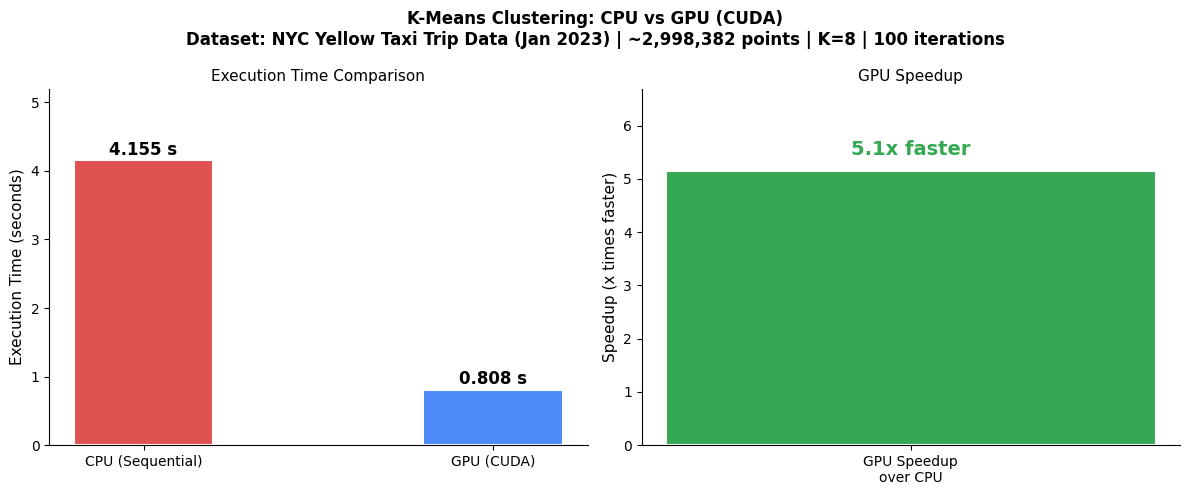


===== FINAL RESULTS =====
Dataset  : NYC Yellow Taxi Trip Data (~2,998,382 points)
CPU time : 4.1552 s
GPU time : 0.8078 s
Speedup  : 5.14x


In [7]:
import matplotlib.pyplot as plt

cpu_time = 4.1552
gpu_time = 0.8078

speedup = cpu_time / gpu_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'K-Means Clustering: CPU vs GPU (CUDA)\n'
    'Dataset: NYC Yellow Taxi Trip Data (Jan 2023) | ~2,998,382 points | K=8 | 100 iterations',
    fontsize=12, fontweight='bold'
)

# Runtime comparison
bars = axes[0].bar(
    ['CPU (Sequential)', 'GPU (CUDA)'],
    [cpu_time, gpu_time],
    color=['#E05252', '#4C8BF5'], width=0.4,
    edgecolor='white', linewidth=1.5
)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[0].set_title('Execution Time Comparison', fontsize=11)
axes[0].set_ylim(0, cpu_time * 1.25)
for bar, val in zip(bars, [cpu_time, gpu_time]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + cpu_time * 0.02,
        f'{val:.3f} s', ha='center',
        fontweight='bold', fontsize=12
    )
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Speedup
axes[1].bar(
    ['GPU Speedup\nover CPU'], [speedup],
    color='#34A853', width=0.3,
    edgecolor='white', linewidth=1.5
)
axes[1].set_ylabel('Speedup (x times faster)', fontsize=11)
axes[1].set_title('GPU Speedup', fontsize=11)
axes[1].set_ylim(0, speedup * 1.3)
axes[1].text(
    0, speedup + speedup * 0.06,
    f'{speedup:.1f}x faster',
    ha='center', fontweight='bold',
    fontsize=14, color='#34A853'
)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n===== FINAL RESULTS =====')
print(f'Dataset  : NYC Yellow Taxi Trip Data (~2,998,382 points)')
print(f'CPU time : {cpu_time:.4f} s')
print(f'GPU time : {gpu_time:.4f} s')
print(f'Speedup  : {speedup:.2f}x')
print(f'=========================')